# S2-5 実データ日次カーブ構築パイプライン

## 学習目標

- 毎日回せる頑健なイールドカーブ構築パイプラインを、入力検証から品質検査まで
  一気通貫で関数化できる
- インプット検証・外れ値検出・前日比較・単調性チェックを、なぜ必要かとともに
  実装できる
- 構築失敗時のフォールバック設計とログ設計を、ポイントインタイム性を壊さずに
  組める
- 60営業日ぶんのゼロレート時系列を再現可能に構築し、前日比 2σ 超の異常日を
  自動で検出・可視化できる

S2 でブートストラップの理論と実装は済んでいる。本 notebook はそれを「毎朝
自動で回す運用系」に仕立て直す。単発の計算ではなく、壊れないパイプラインを
作ることが主題になる。

## 実務での位置づけ（ファンドはどう稼ぐか）

日次カーブ構築パイプラインは、フロントのクオンツとリスク管理が運用系として支える基盤で、その日のカーブは金利デスク・RVファンド・運用会社のすべてが下流で使います。単発の計算が正しくても、毎朝壊れずに回り、汚れた入力を弾き、失敗しても止まらない仕組みがなければ実務では使えません。ここで作るカーブが全ポジションのマーク・P&L・リスク量の共通の入力になるため、パイプラインの頑健性は、そのまま運用全体の評価の信頼性を決めます。

収益とリスク管理への繋がりは、品質を守ることそのものにあります。壊れたカーブが一本流れれば、ファンド全体のマークが狂い、RVの rich/cheap シグナルは誤作動し、リスク量も過小・過大に出ます。入力検証・外れ値検出・前日比較・単調性チェックは、こうした事故を朝の段階で止めるための仕組みです。とりわけ、過去を再現するときにその日時点で入手できた情報だけを使うポイントインタイム性を壊さないことが重要で、これが崩れると先読みが混入し、RV戦略のバックテストが実態より良く見えて、実運用で通用しない戦略に賭けてしまいます。

具体的には、60営業日ぶんのゼロレート時系列を再現可能に構築し、前日比2σ超の異常日を自動検出して、構築失敗時にはフォールバックとログで安全に縮退する、といった運用を組みます。個々のブートストラップやフィットが正しいことと、それを毎日安全に回せることは別の技能で、後者がなければどれだけ精緻なモデルも本番の値洗いには載せられません。


## 理論：実務のカーブ運用

カーブ構築を1回きりの計算として書くのは易しい。難しいのは、汚れた入力・
欠測・システム障害が混じる現実のデータを、毎営業日・無人で・同じ品質で
回し続けることである。ここでは運用系に必要な設計要素を整理する。

### インプット検証（input validation）

パイプラインの出力品質は入力品質を超えない。カーブに渡す前に、パー利回りが
満たすべき前提を機械的に確認する。

- **欠損**：テナーが1つでも欠ければ、その日のカーブは全テナーが揃うまで
  構築を保留するか、フォールバックへ回す。欠損を暗黙にゼロや前値で埋めない。
- **定義域**：パー利回りは常識的な帯（例：$-1\%$ 〜 $20\%$）に収まるべき。
  帯の外は入力ソース側のエラー（単位取り違え・桁ずれ）を疑う。
- **型・単位**：小数（$0.0435$）とパーセント（$4.35$）の取り違えは頻出する
  事故で、$100$ 倍のカーブを生む。単位を1か所で固定して検証する。

### 外れ値検出（outlier detection）

帯の中に収まっていても、前日から不自然に飛んだ点は疑わしい。ここでは
**前日比の $z$ スコア**を使う。テナー $i$ の当日変化を
$\Delta_i = z_i^{(t)} - z_i^{(t-1)}$ とし、そのテナーの変化の標準偏差
$\sigma_i$ に対して

$$ \left| \frac{\Delta_i - \mu_i}{\sigma_i} \right| > k $$

を満たす点を警告する（既定 $k=2$）。市場が実際に大きく動いた日も引っかかるが、
「機械が黙って通す」よりは「人が一度見る」方が安全側に倒れる。閾値は感度と
誤検知のトレードオフで決める運用パラメータである。

### 前日比較（day-over-day comparison）

前日カーブは最も安価な回帰テストの基準になる。当日の構築結果を前日と比べ、
想定外の水準変化・符号反転・形状の破綻を検出する。前日比較は外れ値検出の
土台であり、フォールバック時の代替値の供給源でもある。

### 単調性・無裁定チェック

構築後のカーブそのものの健全性も確認する。健全な割引カーブは次を満たす。

- **割引係数の単調減少**：$DF(t)$ は $t$ について狭義単調に減少する
  （$0 < DF(t_{i+1}) < DF(t_i) \le 1$）。
- **フォワードの非負**：任意区間の連続複利フォワード
  $f(t_1,t_2) = \dfrac{\ln DF(t_1) - \ln DF(t_2)}{t_2 - t_1} \ge 0$。

フォワードが負になるのは、隣り合うテナーの入力が整合しない（1つが外れ値）
典型的な兆候で、外れ値検出をすり抜けた汚れを最後に捕まえる網になる。

### リグレッションテスト（regression test）

パイプラインには「常に成り立つべき不変条件」を埋め込み、毎回検証する。
本パイプラインの中核となる不変条件は**パー再現**である。ブートストラップは
各テナーのパー債が価格 $1$ になる条件から $DF$ を解くので、構築後のカーブで
パー債を再評価すれば価格は $1$ に戻らねばならない。

$$ \frac{c_i}{f} \sum_{k \le i} DF(t_k) + DF(t_i) = 1 $$

これが崩れればブートストラップの実装（あるいは補間）が壊れた合図で、
ライブラリ変更時の回帰を検知できる。

### フォールバック設計（fallback）

入力が検証に通らない、または構築後カーブが品質チェックを通らない日は、
**例外で全体を止めない**。運用系は「今日のカーブ」を必ず1本返す責務がある。
本パイプラインの縮退方針は明快に一つ：**直近で品質を通った最後のカーブ
（last known good）を持ち越す**。持ち越したことは必ずログに残し、後で人が
追える状態にする。単純な規則ほど障害時に信頼できる。

### ログ設計（logging）

無人運用では、後から「なぜこの日はこうなったか」を再構成できることが命綱に
なる。各営業日について「構築成功/フォールバック」「検出した警告」「フォール
バック理由」を構造化レコードとして残す。ログは可視化・監査・障害解析の
一次資料になる。

### ポイントインタイム性（point-in-time）

各日のカーブは、**その日までに入手可能だった情報だけ**で作らねばならない。
未来の値で欠損を補う・将来の統計で当日を正規化するといった**先読み
（look-ahead）**は、バックテストの成績を実運用では再現不能な形で水増しする。
前日比較・外れ値統計・フォールバックはいずれも「過去と当日」だけを参照する
よう組む。これがポイントインタイム性の担保である。

## スクラッチ実装

上の設計要素を、単体で使える関数に落とす。パイプラインは小さな純粋関数の
合成として組み、各段が単独でテスト可能な形にする。

### 使用する自作関数

| 関数 | 引数 | 返り値 | 役割 |
|---|---|---|---|
| `load_par_panel(path)` | CSVパス | `DataFrame`（行=日付, 列=テナー） | 日次パー利回りパネルを読み、縦持ちを横持ちへ整形 |
| `validate_inputs(row, prev_row, sigma, k, band)` | 当日行, 前日行, テナー別σ, 閾値, 定義域帯 | 警告リスト（`dict`） | 欠損・定義域・前日比2σ超を検査 |
| `build_curve(tenors, par_rates, frequency)` | テナー配列, パー利回り, 頻度 | `DiscountCurve` | 1日分のブートストラップ構築 |
| `check_curve_quality(curve, tenors)` | カーブ, テナー配列 | 警告リスト（`dict`） | DF単調減少とフォワード非負を検査 |
| `par_reproduction_error(curve, tenors, par_rates, frequency)` | カーブ, テナー, パー利回り, 頻度 | 最大絶対誤差（`float`） | パー再現の不変条件を検証 |
| `run_pipeline(panel, frequency, k)` | パネル, 頻度, 閾値 | `(ゼロレートDF, ログDF)` | 全日を無停止で構築し品質ログを残す |
| `detect_2sigma_moves(zero_df, k)` | ゼロレート時系列, 閾値 | 警告 `DataFrame` | 前日比kσ超の (日付,テナー) を抽出 |

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = ["Hiragino Sans", "Yu Gothic", "Meiryo", "IPAexGothic", "Noto Sans CJK JP", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
from bondlab.curve import bootstrap_par, DiscountCurve

# 再現性のため乱数種を固定する（本文では乱数を使わないが、演習の外れ値注入で使う）。
np.random.seed(0)

# パー利回りの常識的な定義域（小数）。この帯の外は入力エラーを疑う。
PAR_BAND = (-0.01, 0.20)

### データ読み込み

パネルは縦持ち（`date, tenor, par_yield`）で配布されている。日付×テナーの
横持ちに直すと、以降の日次処理と前日比較が素直に書ける。

In [2]:
def load_par_panel(path) -> pd.DataFrame:
    """日次パー利回りパネル CSV を (行=日付, 列=テナー) の DataFrame に整形する。"""
    raw = pd.read_csv(path)
    expected = {"date", "tenor", "par_yield"}
    if set(raw.columns) != expected:
        raise ValueError(f"想定外の列: {list(raw.columns)}（期待 {sorted(expected)}）")
    raw["date"] = pd.to_datetime(raw["date"])
    panel = raw.pivot(index="date", columns="tenor", values="par_yield")
    panel = panel.sort_index().sort_index(axis=1)
    return panel


DATA_PATH = Path("data") / "samples" / "synthetic_ust_par_panel.csv"
panel = load_par_panel(DATA_PATH)
TENORS = np.asarray(panel.columns, dtype=float)

print("パネル形状 (日数, テナー数):", panel.shape)
print("期間:", panel.index.min().date(), "〜", panel.index.max().date())
print("テナー(年):", [float(t) for t in TENORS])
print("欠損セル数:", int(panel.isna().sum().sum()))
print("\n先頭3日（パー利回り, %表示）:")
display((panel.head(3) * 100).round(3))

パネル形状 (日数, テナー数): (60, 9)
期間: 2026-01-02 〜 2026-03-26
テナー(年): [0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0, 20.0, 30.0]
欠損セル数: 0

先頭3日（パー利回り, %表示）:


tenor,0.5,1.0,2.0,3.0,5.0,7.0,10.0,20.0,30.0
date,,,,,,,,,
2026-01-02,2.818,3.082,3.481,3.757,4.080,4.241,4.350,4.438,4.460
2026-01-05,2.817,3.081,3.480,3.755,4.079,4.239,4.347,4.433,4.453
2026-01-06,2.815,3.079,3.478,3.753,4.076,4.235,4.343,4.426,4.443


### インプット検証と外れ値検出

`validate_inputs` は当日1行を受け取り、警告のリストを返す。欠損・定義域は
前日情報なしで判定できる。前日比 2σ 超は前日行とテナー別の標準偏差を要する。
**前日と当日しか参照しない**ので、ポイントインタイム性を壊さない。

In [3]:
def validate_inputs(row, prev_row=None, sigma=None, k=2.0, band=PAR_BAND):
    """当日のパー利回り行を検証し、警告 dict のリストを返す（空なら健全）。"""
    warnings = []
    vals = row.to_numpy(dtype=float)

    # (1) 欠損：1つでも欠ければ全テナーが揃うまで構築を保留する材料にする。
    missing = row.index[np.isnan(vals)].tolist()
    if missing:
        warnings.append({"type": "missing", "tenors": missing,
                         "detail": f"{len(missing)}テナー欠損"})

    # (2) 定義域：常識的な帯の外は単位取り違え等を疑う。
    lo, hi = band
    oob = row.index[(vals < lo) | (vals > hi)].tolist()
    if oob:
        warnings.append({"type": "out_of_band", "tenors": oob,
                         "detail": f"帯[{lo:.0%},{hi:.0%}]外"})

    # (3) 前日比 2σ 超：前日行とテナー別σがある日のみ。先読みはしない。
    if prev_row is not None and sigma is not None:
        delta = vals - prev_row.to_numpy(dtype=float)
        sig = np.where(sigma > 0, sigma, np.nan)
        z = np.abs(delta) / sig
        spikes = row.index[z > k].tolist()
        if spikes:
            warnings.append({"type": "spike_2sigma", "tenors": spikes,
                             "detail": f"前日比{k:.0f}σ超"})
    return warnings

### カーブ構築とカーブ品質チェック

構築そのものは `bondlab.curve.bootstrap_par` に委ねる。パイプライン側の責務は、
構築**後**のカーブが健全か（割引係数が単調に減り、フォワードが非負か）を
独立に検査することである。

In [4]:
def build_curve(tenors, par_rates, frequency=1) -> DiscountCurve:
    """1日分のパー利回りから割引カーブをブートストラップする薄いラッパ。"""
    return bootstrap_par(tenors, par_rates, frequency=frequency)


def check_curve_quality(curve, tenors):
    """構築後カーブの健全性（DF単調減少・フォワード非負）を検査する。"""
    t = np.asarray(tenors, dtype=float)
    warnings = []
    dfs = curve.discount(t)

    # (1) 割引係数の単調減少：DF は t について狭義単調に減るはず。
    if np.any(np.diff(dfs) >= 0) or np.any(dfs <= 0) or np.any(dfs > 1.0 + 1e-12):
        warnings.append({"type": "df_not_monotone",
                         "detail": "割引係数が単調減少でない/範囲外"})

    # (2) フォワード非負：隣接テナー区間の連続複利フォワードが負なら無裁定を破る。
    fwd = (np.log(dfs[:-1]) - np.log(dfs[1:])) / (t[1:] - t[:-1])
    if np.any(fwd < 0):
        warnings.append({"type": "negative_forward",
                         "detail": f"最小フォワード {fwd.min() * 100:.3f}%"})
    return warnings

### パー再現（リグレッションテスト）

パイプラインの中核不変条件。構築したカーブで各テナーのパー債を再評価し、
価格が $1$ に戻る最大誤差を返す。理論上ゼロ（数値誤差のみ）でなければならない。

In [5]:
def par_reproduction_error(curve, tenors, par_rates, frequency=1):
    """各テナーのパー債価格が 1 に戻るかを検証し、最大絶対誤差を返す。"""
    t = np.asarray(tenors, dtype=float)
    c = np.asarray(par_rates, dtype=float)
    dfs = curve.discount(t)
    cpn = c / frequency
    prices = np.array([cpn[i] * dfs[: i + 1].sum() + dfs[i] for i in range(len(t))])
    return float(np.max(np.abs(prices - 1.0)))

### パイプライン本体

全日を先頭から順に処理する。各日で「入力検証 → 構築 → カーブ品質 → パー再現」
を回し、どれかが致命的なら**直近の good カーブを持ち越す**フォールバックに
落ちる。致命的でない警告（前日比 2σ 超など）は構築を止めず、ログにだけ残す。

テナー別 $\sigma$ は**前日までの実現変化**から逐次更新する（先読み防止）。

In [6]:
def run_pipeline(panel, frequency=1, k=2.0, band=PAR_BAND, min_history=5):
    """日次パネルを無停止で処理し、(ゼロレートDF, ログDF) を返す。"""
    tenors = np.asarray(panel.columns, dtype=float)
    dates = panel.index

    zero_rows = {}          # date -> ゼロレート配列（採用したカーブ由来）
    logs = []               # 1日1レコードの構造化ログ
    last_good_curve = None  # フォールバック用 last known good
    changes = []            # 前日比変化の履歴（σ推定用, ポイントインタイム）
    prev_vals = None

    for d in dates:
        row = panel.loc[d]
        # 前日までの履歴からテナー別σを作る（当日は含めない）。
        sigma = (np.nanstd(np.vstack(changes), axis=0)
                 if len(changes) >= min_history else None)

        in_warn = validate_inputs(row, prev_row=panel.loc[prev_vals] if prev_vals is not None else None,
                                  sigma=sigma, k=k, band=band)
        fatal = any(w["type"] in ("missing", "out_of_band") for w in in_warn)

        status, fb_reason, curve = "ok", None, None
        curve_warn, par_err = [], np.nan

        if fatal:
            status, fb_reason = "fallback", "入力検証で致命的警告"
        else:
            curve = build_curve(list(tenors), row.to_numpy(dtype=float), frequency)
            curve_warn = check_curve_quality(curve, tenors)
            par_err = par_reproduction_error(curve, tenors, row.to_numpy(dtype=float), frequency)
            if curve_warn or par_err > 1e-8:
                status, fb_reason = "fallback", "カーブ品質検査で不合格"

        if status == "fallback":
            if last_good_curve is None:
                # 初日から不合格なら持ち越す先が無い。NaN 行として記録し先へ進む。
                zero_rows[d] = np.full(len(tenors), np.nan)
            else:
                zero_rows[d] = last_good_curve.zero_rate(tenors)
        else:
            last_good_curve = curve
            zero_rows[d] = curve.zero_rate(tenors)

        # σ推定履歴の更新（先読み防止のため当日確定後に積む）。
        if prev_vals is not None:
            changes.append(row.to_numpy(dtype=float) - panel.loc[prev_vals].to_numpy(dtype=float))
        prev_vals = d

        logs.append({
            "date": d, "status": status, "fallback_reason": fb_reason,
            "n_input_warn": len(in_warn), "n_curve_warn": len(curve_warn),
            "par_err": par_err,
            "spike": any(w["type"] == "spike_2sigma" for w in in_warn),
        })

    zero_df = pd.DataFrame(zero_rows).T
    zero_df.columns = tenors
    zero_df.index.name = "date"
    log_df = pd.DataFrame(logs).set_index("date")
    return zero_df, log_df

## QuantLib 検証

本 notebook の検証は QuantLib との突合ではなく、**「パー再現」と「全日構築
成功」という2つの不変条件**に置き換える。理由は二つ。第一に、この運用系で
守りたい不変条件はライブラリ横断の一致ではなく、自前パイプラインが日々
同じ品質を出し続けることだからである。第二に、パー再現はブートストラップの
定義そのものに対する回帰テストとして QuantLib と同等以上に鋭い（実装が
壊れれば即座に破れる）。以下ではこの2条件を全60営業日で確認する。

In [7]:
zero_df, log_df = run_pipeline(panel, frequency=1, k=2.0)

n_days = len(log_df)
n_ok = int((log_df["status"] == "ok").sum())
n_fb = int((log_df["status"] == "fallback").sum())
max_par_err = float(log_df["par_err"].max(skipna=True))

print(f"処理営業日数        : {n_days}")
print(f"構築成功            : {n_ok}")
print(f"フォールバック      : {n_fb}")
print(f"パー再現の最大誤差  : {max_par_err:.2e}")
print(f"ゼロレートの欠損セル: {int(zero_df.isna().sum().sum())}")

# リグレッションテスト：全日成功・パー再現・欠損ゼロを明示的に守る。
assert n_ok == n_days, "全日構築に成功していない"
assert max_par_err < 1e-8, "パー再現が崩れている"
assert zero_df.isna().sum().sum() == 0, "ゼロレートに欠損がある"
print("\n検証を通過：全60営業日で構築成功、かつパー再現が成立")

処理営業日数        : 60
構築成功            : 60
フォールバック      : 0
パー再現の最大誤差  : 2.22e-16
ゼロレートの欠損セル: 0

検証を通過：全60営業日で構築成功、かつパー再現が成立


/var/folders/1g/1cr93g5j1yn9cmnn2nz4ydt40000gn/T/ipykernel_4212/3685417761.py:3: UserWarning: bootstrap_par: テナーが等間隔でない。間のクーポン払込日を無視してカーブが歪む可能性がある。1/frequency 刻みのグリッドへ補間してから渡すことを推奨。
  return bootstrap_par(tenors, par_rates, frequency=frequency)


### 1日サンプルでのパー再現の詳細

初日について、構築カーブが各テナーのパー債をパーで再現することを個別に示す。

In [8]:
sample_date = panel.index[0]
sample_row = panel.loc[sample_date]
curve0 = build_curve(list(TENORS), sample_row.to_numpy(dtype=float), frequency=1)

dfs0 = curve0.discount(TENORS)
cpn0 = sample_row.to_numpy(dtype=float)
prices0 = np.array([cpn0[i] * dfs0[: i + 1].sum() + dfs0[i] for i in range(len(TENORS))])

detail = pd.DataFrame({
    "テナー(年)": TENORS,
    "パー利回り(%)": (cpn0 * 100).round(3),
    "割引係数": dfs0.round(6),
    "ゼロレート(%)": (curve0.zero_rate(TENORS) * 100).round(4),
    "パー債価格": prices0.round(10),
})
print(f"サンプル日: {sample_date.date()}")
display(detail)
print(f"\nパー債価格の最大誤差: {np.max(np.abs(prices0 - 1.0)):.2e}")

サンプル日: 2026-01-02


/var/folders/1g/1cr93g5j1yn9cmnn2nz4ydt40000gn/T/ipykernel_4212/3685417761.py:3: UserWarning: bootstrap_par: テナーが等間隔でない。間のクーポン払込日を無視してカーブが歪む可能性がある。1/frequency 刻みのグリッドへ補間してから渡すことを推奨。
  return bootstrap_par(tenors, par_rates, frequency=frequency)


,テナー(年),パー利回り(%),割引係数,ゼロレート(%),パー債価格
0,0.5,2.818,0.972592,5.5580,1.0
1,1.0,3.082,0.941022,6.0788,1.0
2,2.0,3.481,0.901989,5.1577,1.0
3,3.0,3.757,0.861839,4.9562,1.0
4,5.0,4.080,0.816641,4.0511,1.0
5,7.0,4.241,0.776476,3.6141,1.0
6,10.0,4.350,0.738602,3.0300,1.0
7,20.0,4.438,0.702152,1.7680,1.0
8,30.0,4.460,0.670760,1.3311,1.0



パー債価格の最大誤差: 1.11e-16


## 実データ適用

60営業日ぶんのゼロレート時系列をヒートマップとラインで可視化し、前日比 2σ
超の警告が出た (日付, テナー) を検出して重ねて表示する。

In [9]:
def detect_2sigma_moves(zero_df, k=2.0):
    """ゼロレート時系列から前日比 kσ 超の (日付, テナー) を抽出する。"""
    dz = zero_df.diff()                       # 前日比（初日は NaN）
    sigma = dz.std(axis=0)                     # テナー別の変化標準偏差
    z = dz.divide(sigma.replace(0, np.nan), axis=1)
    mask = z.abs() > k
    flags = [{"date": d, "tenor": t,
              "change_bp": dz.loc[d, t] * 1e4, "zscore": z.loc[d, t]}
             for d in mask.index for t in mask.columns if bool(mask.loc[d, t])]
    return pd.DataFrame(flags)


flags = detect_2sigma_moves(zero_df, k=2.0)
print(f"前日比2σ超の警告点: {len(flags)} 件")
if not flags.empty:
    top = flags.reindex(flags["zscore"].abs().sort_values(ascending=False).index)
    print("\n変動が大きい上位10点:")
    show = top.head(10).copy()
    show["date"] = show["date"].dt.date
    show["change_bp"] = show["change_bp"].round(2)
    show["zscore"] = show["zscore"].round(2)
    display(show)

前日比2σ超の警告点: 23 件

変動が大きい上位10点:


,date,tenor,change_bp,zscore
14,2026-01-21,10.0,-1.65,-2.77
15,2026-01-21,20.0,-1.03,-2.76
12,2026-01-21,5.0,-2.24,-2.70
9,2026-01-21,1.0,-4.47,-2.67
10,2026-01-21,2.0,-3.35,-2.67
11,2026-01-21,3.0,-2.98,-2.66
13,2026-01-21,7.0,-1.92,-2.65
8,2026-01-21,0.5,-4.48,-2.65
22,2026-03-12,30.0,-0.82,-2.56
16,2026-01-21,30.0,-0.77,-2.41


### ゼロレート曲面のヒートマップ

findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


...

findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


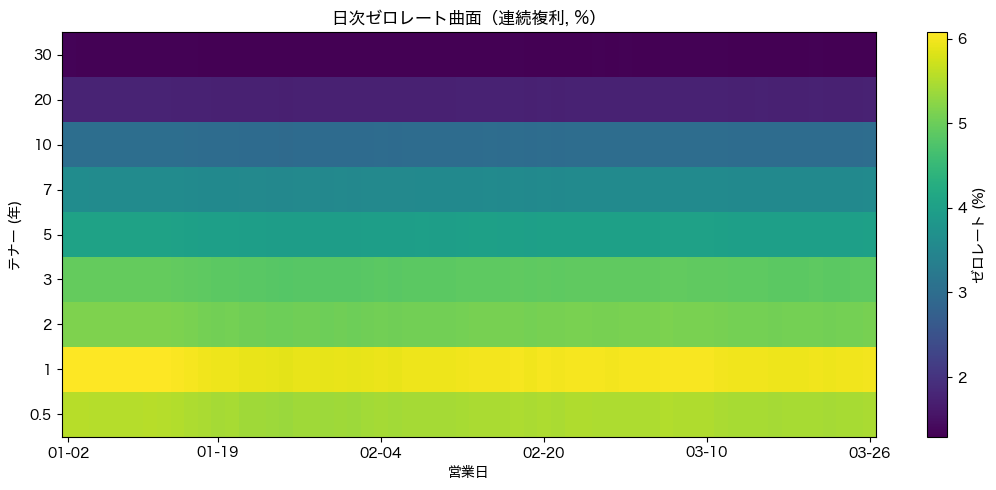

In [10]:
fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow((zero_df.values * 100).T, aspect="auto", cmap="viridis", origin="lower")
ax.set_yticks(range(len(TENORS)))
ax.set_yticklabels([f"{t:g}" for t in TENORS])
xt = np.linspace(0, len(zero_df) - 1, 6, dtype=int)
ax.set_xticks(xt)
ax.set_xticklabels([zero_df.index[i].strftime("%m-%d") for i in xt])
ax.set_xlabel("営業日")
ax.set_ylabel("テナー (年)")
ax.set_title("日次ゼロレート曲面（連続複利, %）")
fig.colorbar(im, ax=ax, label="ゼロレート (%)")
fig.tight_layout()
plt.show()

### ゼロレートのライン推移と 2σ 警告点

代表テナーのゼロレート推移に、`detect_2sigma_moves` が拾った警告点を重ねる。
警告は「その日に人が一度見るべき点」であり、必ずしも異常とは限らない。

findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


...

findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


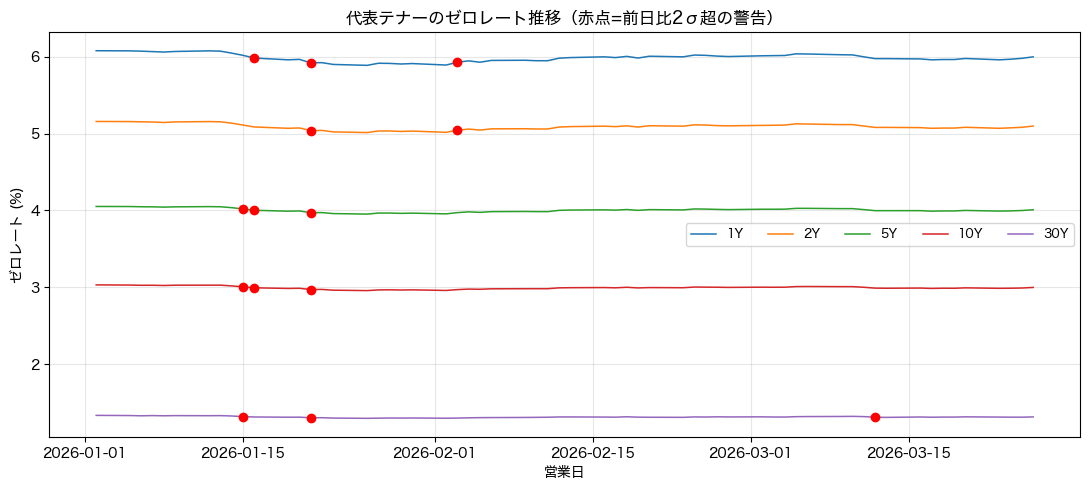

In [11]:
fig, ax = plt.subplots(figsize=(11, 5))
show_tenors = [t for t in (1.0, 2.0, 5.0, 10.0, 30.0) if t in TENORS]
for t in show_tenors:
    ax.plot(zero_df.index, zero_df[t] * 100, lw=1.1, label=f"{t:g}Y")
    sub = flags[flags["tenor"] == t] if not flags.empty else pd.DataFrame()
    if not sub.empty:
        ax.scatter(sub["date"], zero_df.loc[sub["date"], t] * 100,
                   color="red", zorder=5, s=36, marker="o")
ax.set_xlabel("営業日")
ax.set_ylabel("ゼロレート (%)")
ax.set_title("代表テナーのゼロレート推移（赤点=前日比2σ超の警告）")
ax.legend(ncol=len(show_tenors), fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

合成データなので水準そのものに市場的な意味はない。ここで確認したいのは、
(1) 60営業日を無停止で構築できること、(2) 各日のカーブがパー債を再現する
こと、(3) 前日比 2σ 超の日を機械的に拾い、可視化に重ねられることである。

## 演習

1. **2σ 警告チェッカーの実装と大変動日の検出**：本文の `detect_2sigma_moves`
   を参考に、テナー別ではなく**「その日の全テナー合計の異常度」**で日を
   ランク付けする関数を書け。各日について $\sqrt{\sum_i z_i^2}$（$z_i$ は
   テナー $i$ の前日比 $z$ スコア）を集計し、値が大きい上位5営業日を表に
   せよ。テナー単位の警告と日単位の警告で、拾われる日がどう違うかを一言で
   述べよ。
2. **外れ値注入とフォールバックの発火確認**：パネルのある1日・1テナーに
   意図的な外れ値（例：定義域外の $50\%$）を差し込み、`run_pipeline` を
   回せ。その日が `fallback` になり、ゼロレートが前日の値を持ち越している
   こと、そして**翌日以降は正常な構築に復帰**することを確認せよ。

解答例は `solutions/S2/sol_0205.py` に置く。

## 用語集

定義の正は `glossary/02_curves.md`。ここでは初出語の一行要約のみ示す。

| 用語 | 英語 | 一行定義 |
|---|---|---|
| ポイントインタイム | point-in-time | 各時点の計算にその時点までの情報のみを使い、先読みを排する原則 |
| 外れ値検出 | outlier detection | 前日比 $z$ スコア等で、疑わしい入力点を機械的に警告する仕組み |
| リグレッションテスト | regression test | 常に成り立つ不変条件（例：パー再現）を毎回検証し、退行を捕える |
| フォールバック | fallback | 構築失敗時に直近の good カーブを持ち越し、運用を止めない縮退設計 |